# Stop Re-running: Efficient Numerical Integration via Solver Log and Resumption

Original QMCPy demo: [`QMCPy/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb`](../../../QMCPy/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb)

This Julia version compares the same two workflows: solving each tolerance from scratch versus progressively resuming from the previous tolerance.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb)

Parity note: QMCPy runs the same two-workflow comparison on `Keister(Gaussian(Lattice(3, seed=7)))` across 9 tolerances from `1e-3` down to `3.90625e-6`. The checked-in Julia notebook keeps the same fresh-versus-resume panels and the same seeded lattice dimension, but uses an oscillatory `Genz(Uniform(Lattice(3; seed=7)))` problem and a shorter tolerance ladder from `1e-3` down to `3.125e-5` to stay within the current lattice sample window.


In [1]:
using QMC
using Printf

function demo_table(rows, columns; caption="")
    io = IOBuffer()
    print(io, "<table>")
    isempty(caption) || print(io, "<caption>", caption, "</caption>")
    print(io, "<thead><tr>")
    foreach(column -> print(io, "<th>", column[2], "</th>"), columns)
    print(io, "</tr></thead><tbody>")
    for row in rows
        print(io, "<tr>")
        foreach(column -> print(io, "<td style=\"text-align:right\">", column[3](getproperty(row, column[1])), "</td>"), columns)
        print(io, "</tr>")
    end
    print(io, "</tbody></table>")
    return Base.HTML(String(take!(io)))
end

format_seconds(x) = abs(x) < 1e-3 ? @sprintf("%.3e", x) : @sprintf("%.3f", x)

summary_columns = [
    (:abs_tol, "abs tol", x -> @sprintf("%.3e", x)),
    (:n_total, "n total", string),
    (:elapsed, "time (s)", format_seconds),
    (:solution, "solution", x -> @sprintf("%.8g", x)),
]

iteration_columns = [
    (:iter, "iter", string),
    (:n, "n", string),
    (:solution, "solution", x -> @sprintf("%.8g", x)),
    (:error_bound, "err bound", x -> @sprintf("%.3e", x)),
    (:tol, "tol", x -> @sprintf("%.3e", x)),
    (:elapsed, "time (s)", format_seconds),
]

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Approach 1. Classic Loop

First solve each requested tolerance from scratch. This is the baseline workflow used for comparison in the original QMCPy notebook and in the summary tables below.


In [2]:
tols = [1e-3 / 2.0^k for k in 0:5]

function make_solver(abs_tol; seed=7)
    dd = Lattice(3; seed=seed)
    f = Genz(Uniform(dd); kind=:oscillatory, a=ones(3), u=0.5 .* ones(3))
    return CubQMCLatticeG(f; abs_tol=abs_tol, trace_iterations=true)
end

function run_fresh_curve()
    rows = NamedTuple[]
    for eps in tols
        r = integrate(make_solver(eps))
        push!(rows, (abs_tol=eps, n_total=r.data[:n_total], elapsed=r.data[:time_integrate], solution=r.solution))
    end
    return rows
end

function run_resume_curve()
    rows = NamedTuple[]
    resume_state = nothing
    cumulative = 0.0
    for eps in tols
        r = isnothing(resume_state) ? integrate(make_solver(eps)) : integrate(make_solver(eps); resume=resume_state)
        cumulative += r.data[:time_integrate]
        stop_row = iterations(r.data[:iteration_log])[end]
        push!(rows, (abs_tol=eps, n_total=r.data[:n_total], elapsed=cumulative, solution=r.solution, stop_row=stop_row))
        resume_state = r.data
    end
    return rows
end

fresh_rows = run_fresh_curve()
resume_rows = run_resume_curve();


## Approach 2. Iteration Log with Resume Approach

The solver is executed by first running it at the loosest tolerance and then resuming at progressively tighter tolerances. Because each resumption starts from the previous state, the cumulative time and sample count grow only as needed.


In [3]:
display(demo_table(fresh_rows, summary_columns; caption="Fresh solves"))
display(demo_table(resume_rows, summary_columns; caption="Progressively resumed solves"))

fresh_total_samples = sum(row.n_total for row in fresh_rows)
resume_total_samples = resume_rows[end].n_total
@printf("Total samples when re-running from scratch: %d
", fresh_total_samples)
@printf("Samples after progressive resumption: %d
", resume_total_samples)
@printf("Sample reuse factor: %.2f×
", fresh_total_samples / resume_total_samples)


abs tol,n total,time (s),solution
1.000e-03,4096,0.019,-0.062423156
5.000e-04,8192,0.008,-0.062328353
2.500e-04,16384,0.001,-0.062307875
1.250e-04,32768,0.003,-0.062335033
6.250e-05,65536,0.008,-0.062359339
3.125e-05,131072,0.069,-0.062361949


abs tol,n total,time (s),solution
1.000e-03,4096,2.501e-04,-0.062423156
5.000e-04,8192,0.026,-0.062328353
2.500e-04,16384,0.052,-0.062307875
1.250e-04,32768,0.080,-0.062335033
6.250e-05,65536,0.115,-0.062359339
3.125e-05,131072,0.157,-0.062361949


Total samples when re-running from scratch: 258048
Samples after progressive resumption: 131072
Sample reuse factor: 1.97×


Below, we inspect the stored stop rows from the iteration log. These are the Julia counterpart to the reviewable iteration log used in the QMCPy notebook.


In [4]:
@assert resume_total_samples < fresh_total_samples
@assert all(abs(f.solution - r.solution) ≤ f.abs_tol for (f, r) in zip(fresh_rows, resume_rows))
demo_table([row.stop_row for row in resume_rows], iteration_columns; caption="Stopping iteration at each tolerance")


iter,n,solution,err bound,tol,time (s)
3,4096,-0.062423156,6.555e-04,1.000e-03,2.501e-04
1,8192,-0.062328353,3.798e-04,5.000e-04,0.022
1,16384,-0.062307875,2.025e-04,2.500e-04,6.740e-04
1,32768,-0.062335033,1.054e-04,1.250e-04,0.002
1,65536,-0.062359339,5.506e-05,6.250e-05,0.007
1,131072,-0.062361949,2.996e-05,3.125e-05,0.008


**Efficiency Visualization.**


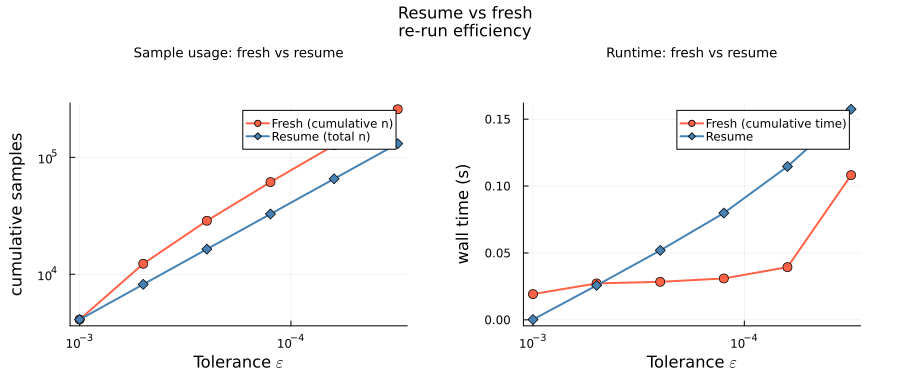

In [5]:
if HAVE_PLOTS
    # Plot: samples used vs tolerance  (fresh re-run vs resume)
    tols_plot    = [row.abs_tol for row in fresh_rows]
    n_fresh      = [row.n_total for row in fresh_rows]
    n_resume     = [row.n_total for row in resume_rows]
    t_fresh      = [row.elapsed for row in fresh_rows]
    t_resume     = [row.elapsed for row in resume_rows]

    p1 = plot(tols_plot, cumsum(n_fresh);
        xscale=:log10, yscale=:log10, xflip=true,
        marker=:circle, lw=2, ms=5, color=:tomato,
        label="Fresh (cumulative n)",
        xlabel="Tolerance \$\\varepsilon\$", ylabel="cumulative samples",
        title="Sample usage: fresh vs resume")
    plot!(tols_plot, n_resume;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="Resume (total n)")

    p2 = plot(tols_plot, cumsum(t_fresh);
        xscale=:log10, xflip=true,
        marker=:circle, lw=2, ms=5, color=:tomato,
        label="Fresh (cumulative time)",
        xlabel="Tolerance \$\\varepsilon\$", ylabel="wall time (s)",
        title="Runtime: fresh vs resume")
    plot!(tols_plot, t_resume;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="Resume")

    display(plot(p1, p2; layout=(1, 2), size=(900, 380),
        plot_titlevspan=0.12, plot_title="Resume vs fresh\nre-run efficiency",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm, left_margin=5Plots.mm))
end


# Conclusions

Across a tolerance ladder, resuming from the previous solve reuses paid-for work and therefore reduces total samples and total runtime relative to restarting every target from scratch.
